# LeafAI CNN experiments

This notebook is a safe workspace for testing training changes. It does **not** overwrite `models/plant_disease_model.keras`, `models/plant_disease_model.h5`, or `models/class_indices.json`. Each run writes to a timestamped folder under `models/experiments/`.

When an experiment is verified, use the final promotion cell to copy it into production.

In [1]:
from pathlib import Path
from datetime import datetime
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make the notebook work whether launched from the repository root or backend folder.
candidates = [Path.cwd(), Path.cwd() / 'leafai' / 'backend', Path.cwd().parent]
BASE_DIR = next((p for p in candidates if (p / 'dataset' / 'PlantVillage' / 'color').exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError('Could not find leafai/backend/dataset/PlantVillage/color')

DATASET_DIR = BASE_DIR / 'dataset' / 'PlantVillage' / 'color'
PRODUCTION_DIR = BASE_DIR / 'models'
RUN_DIR = PRODUCTION_DIR / 'experiments' / datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR.mkdir(parents=True, exist_ok=False)

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 10
SEED = 42
tf.keras.utils.set_random_seed(SEED)
print(f'Dataset: {DATASET_DIR}')
print(f'Experiment output: {RUN_DIR}')

Dataset: c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\dataset\PlantVillage\color
Experiment output: c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927


## 1. Inspect the dataset

Run this before changing augmentation or class weighting. Large differences in class counts can make overall accuracy misleading.

  152  Potato___healthy
  275  Apple___Cedar_apple_rust
  360  Peach___healthy
  371  Raspberry___healthy
  373  Tomato___Tomato_mosaic_virus
  423  Grape___healthy
  456  Strawberry___healthy
  513  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  621  Apple___Black_rot
  630  Apple___Apple_scab
  854  Cherry_(including_sour)___healthy
  952  Tomato___Leaf_Mold
  985  Corn_(maize)___Northern_Leaf_Blight
 1000  Potato___Early_blight
 1000  Potato___Late_blight
 1000  Tomato___Early_blight
 1003  Pepper,_bell___Bacterial_spot
 1052  Cherry_(including_sour)___Powdery_mildew
 1076  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
 1109  Strawberry___Leaf_scorch
 1162  Corn_(maize)___healthy
 1180  Grape___Black_rot
 1192  Corn_(maize)___Common_rust_
 1383  Grape___Esca_(Black_Measles)
 1404  Tomato___Target_Spot
 1478  Pepper,_bell___healthy
 1501  Blueberry___healthy
 1591  Tomato___healthy
 1644  Apple___healthy
 1676  Tomato___Spider_mites Two-spotted_spider_mite
 1771  Tomato___Septoria

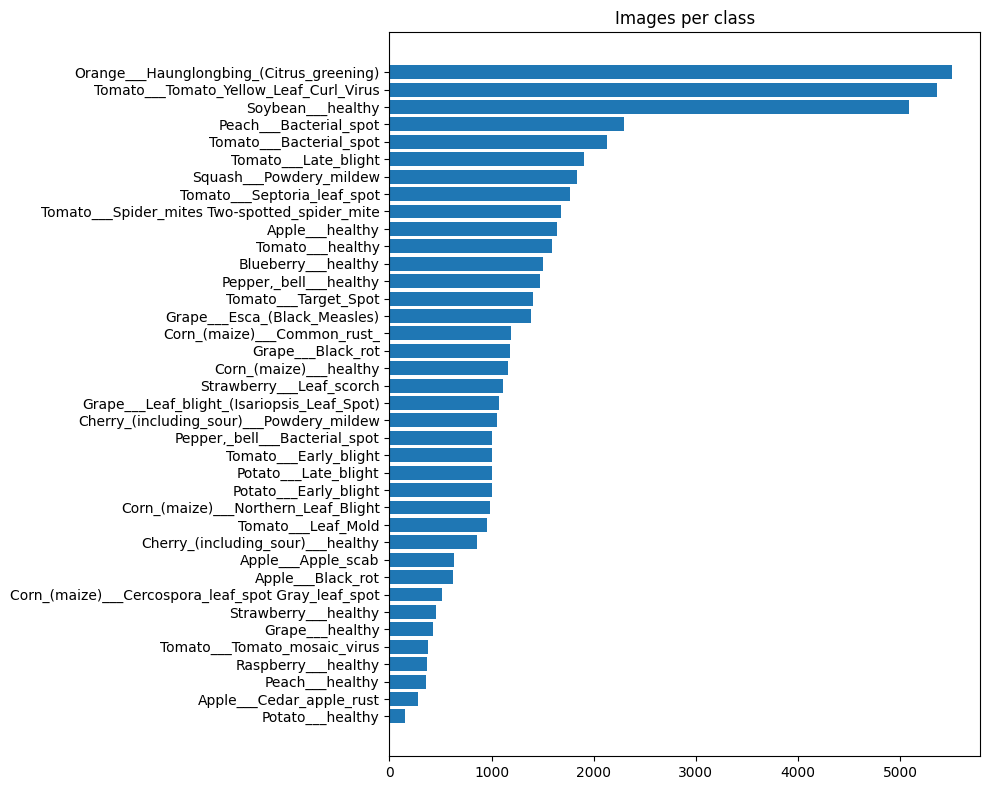

In [2]:
class_counts = {}
for class_dir in sorted(p for p in DATASET_DIR.iterdir() if p.is_dir()):
    class_counts[class_dir.name] = len(list(class_dir.glob('*')))

counts = sorted(class_counts.items(), key=lambda item: item[1])
for name, count in counts:
    print(f'{count:5d}  {name}')

plt.figure(figsize=(10, 8))
plt.barh([name for name, _ in counts], [count for _, count in counts])
plt.title('Images per class')
plt.tight_layout()
plt.show()

## 2. Build generators

Keep this preprocessing identical to the current application while establishing a baseline. If you later switch to MobileNetV2 `preprocess_input`, update the backend prediction preprocessing at the same time.

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    str(DATASET_DIR), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=SEED
)
val_generator = val_datagen.flow_from_directory(
    str(DATASET_DIR), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=SEED
)
print(train_generator.samples, 'training images')
print(val_generator.samples, 'validation images')
print(train_generator.num_classes, 'classes')

Found 43460 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
43460 training images
10849 validation images
38 classes


## 3. Create and train an experiment model

Change only the configuration or architecture in this section. The temporary H5 checkpoint avoids the TensorFlow 2.13 `.keras` checkpoint issue encountered by the production script. The completed model is still saved as `.keras`.

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(*IMG_SIZE, 3)))
base_model.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_path = str(RUN_DIR / 'best_checkpoint.h5')
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
]

history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS, callbacks=callbacks, verbose=1)

# Optional fine-tuning experiment. Change the number of trainable layers here.
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
fine_tune_history = model.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=callbacks, verbose=1)

model_path = str(RUN_DIR / 'plant_disease_model.keras')
model.save(model_path)
with open(RUN_DIR / 'class_indices.json', 'w', encoding='utf-8') as file:
    json.dump(train_generator.class_indices, file, indent=2)
print(f'Saved experiment model to {model_path}')

C:\Users\ABDUL RAHMIN\AppData\Local\Temp\ipykernel_58920\3907404548.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(*IMG_SIZE, 3)))


Epoch 1/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.6555 - loss: 1.2389
Epoch 1: val_accuracy improved from None to 0.85040, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 428s 155ms/step - accuracy: 0.7383 - loss: 0.8781 - val_accuracy: 0.8504 - val_loss: 0.4624 - learning_rate: 0.0010
Epoch 2/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8111 - loss: 0.5983
Epoch 2: val_accuracy improved from 0.85040 to 0.87363, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 427s 157ms/step - accuracy: 0.8127 - loss: 0.5941 - val_accuracy: 0.8736 - val_loss: 0.3903 - learning_rate: 0.0010
Epoch 3/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8277 - loss: 0.5523
Epoch 3: val_accuracy improved from 0.87363 to 0.88165, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 407s 144ms/step - accuracy: 0.8266 - loss: 0.5525 - val_accuracy: 0.8816 - val_loss: 0.3635 - learning_rate: 0.0010
Epoch 4/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8359 - loss: 0.5141
Epoch 4: val_accuracy improved from 0.88165 to 0.88248, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 385s 142ms/step - accuracy: 0.8349 - loss: 0.5219 - val_accuracy: 0.8825 - val_loss: 0.3633 - learning_rate: 0.0010
Epoch 5/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8465 - loss: 0.4917
Epoch 5: val_accuracy did not improve from 0.88248
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 374s 138ms/step - accuracy: 0.8416 - loss: 0.5042 - val_accuracy: 0.8816 - val_loss: 0.3632 - learning_rate: 0.0010
Epoch 6/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8419 - loss: 0.4970
Epoch 6: val_accuracy improved from 0.88248 to 0.89087, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 375s 138ms/step - accuracy: 0.8425 - loss: 0.4996 - val_accuracy: 0.8909 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 7/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8530 - loss: 0.4785
Epoch 7: val_accuracy improved from 0.89087 to 0.89594, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 366s 135ms/step - accuracy: 0.8512 - loss: 0.4825 - val_accuracy: 0.8959 - val_loss: 0.3376 - learning_rate: 0.0010
Epoch 8/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8557 - loss: 0.4665
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 8: val_accuracy did not improve from 0.89594
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 363s 134ms/step - accuracy: 0.8538 - loss: 0.4692 - val_accuracy: 0.8951 - val_loss: 0.3380 - learning_rate: 0.0010
Epoch 9/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8722 - loss: 0.4009
Epoch 9: val_accuracy improved from 0.89594 to 0.90958, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 359s 132ms/step - accuracy: 0.8790 - loss: 0.3776 - val_accuracy: 0.9096 - val_loss: 0.2878 - learning_rate: 3.0000e-04
Epoch 10/10
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8893 - loss: 0.3520
Epoch 10: val_accuracy improved from 0.90958 to 0.91308, saving model to c:\Users\ABDUL RAHMIN\Documents\Aurak\Archived Semesters\Senior Design Project\plant monitoring system\leafai\backend\models\experiments\20260904_172927\best_checkpoint.h5


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 365s 134ms/step - accuracy: 0.8890 - loss: 0.3531 - val_accuracy: 0.9131 - val_loss: 0.2710 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 10.
Epoch 1/5
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6494 - loss: 1.5668
Epoch 1: val_accuracy did not improve from 0.91308
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 454s 163ms/step - accuracy: 0.7256 - loss: 1.0222 - val_accuracy: 0.8719 - val_loss: 0.4157 - learning_rate: 1.0000e-05
Epoch 2/5
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8050 - loss: 0.6468
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 2: val_accuracy did not improve from 0.91308
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 505s 186ms/step - accuracy: 0.8166 - loss: 0.6016 - val_accuracy: 0.9020 - val_loss: 0.3073 - learning_rate: 1.0000e-05
Epoch 3/5
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8458 - loss: 0.5086
Epoch 3: val_accuracy did not improve fr

## 4. Evaluate the experiment

Do not rely on overall accuracy alone. Review the per-class report and confusion matrix before promoting a model.

679/679 ━━━━━━━━━━━━━━━━━━━━ 52s 75ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.887     0.500     0.640       126
                                 Apple___Black_rot      0.831     0.871     0.850       124
                          Apple___Cedar_apple_rust      0.939     0.836     0.885        55
                                   Apple___healthy      0.849     0.927     0.886       328
                               Blueberry___healthy      0.916     0.910     0.913       300
          Cherry_(including_sour)___Powdery_mildew      0.995     0.924     0.958       210
                 Cherry_(including_sour)___healthy      0.852     0.947     0.897       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.747     0.637     0.688       102
                       Corn_(maize)___Common_rust_      0.918     0.992     0.954       238
               Corn_(maize)___Northe

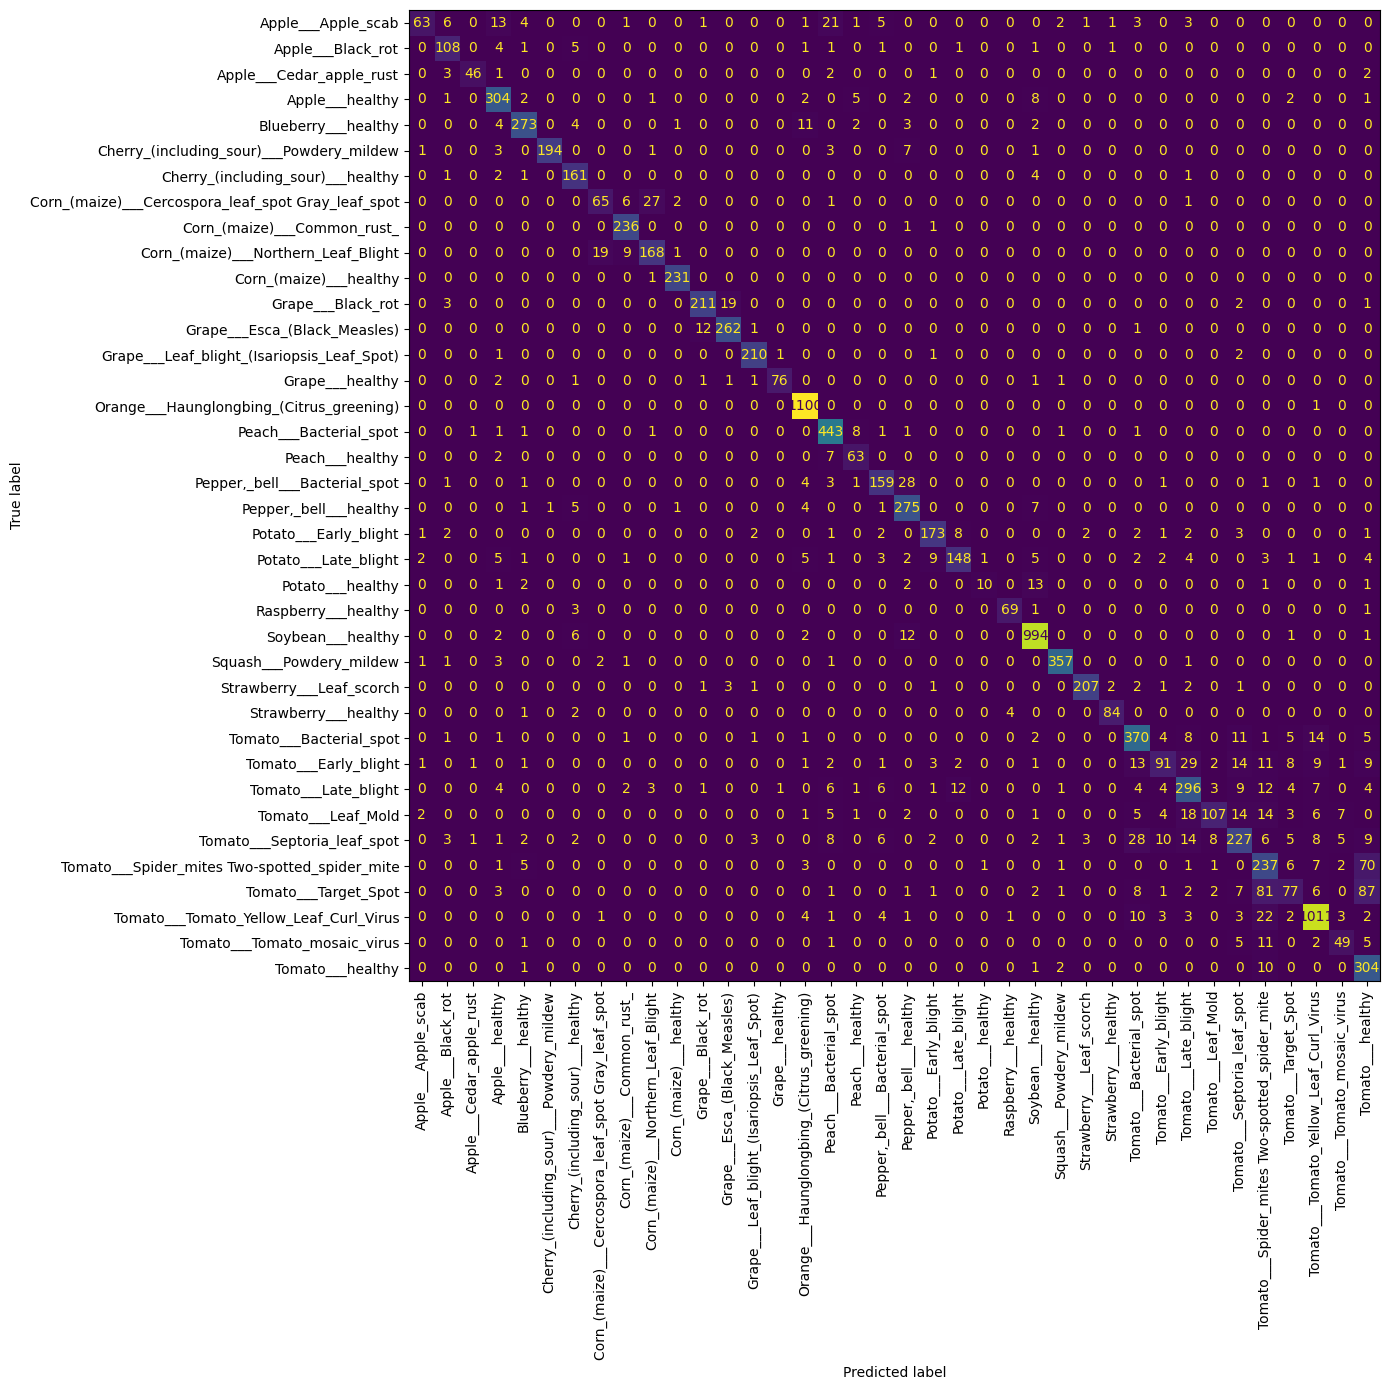

In [6]:
val_generator.reset()
probabilities = model.predict(val_generator, verbose=1)
predicted = np.argmax(probabilities, axis=1)
actual = val_generator.classes
labels = list(val_generator.class_indices.keys())

print(classification_report(actual, predicted, target_names=labels, zero_division=0, digits=3))
print('Overall validation accuracy:', f'{np.mean(predicted == actual) * 100:.2f}%')

cm = confusion_matrix(actual, predicted)
fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.tight_layout()
plt.show()

## 5. Promote only after review

This cell is disabled by default. Set `PROMOTE = True` only after checking the evaluation results. It copies the experiment model and class mapping into the production model directory.

In [8]:
PROMOTE = True
if PROMOTE:
    shutil.copy2(RUN_DIR / 'plant_disease_model.keras', PRODUCTION_DIR / 'plant_disease_model.keras')
    shutil.copy2(RUN_DIR / 'class_indices.json', PRODUCTION_DIR / 'class_indices.json')
    print('Promoted experiment to production.')
    print('Restart the backend and refresh model performance with Y when prompted.')
else:
    print('Promotion skipped. Production model was not changed.')

Promoted experiment to production.
Restart the backend and refresh model performance with Y when prompted.
